<a href="https://colab.research.google.com/github/huyryan220806/HR-Analyst/blob/main/HRAnalyst.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# -*- coding: utf-8 -*-
"""
=============================================================================
ĐỒ ÁN CUỐI KỲ: PHÂN TÍCH DỮ LIỆU NHÂN SỰ (HR ANALYST)
DỰ ĐOÁN NGUY CƠ NGHỈ VIỆC CỦA NHÂN VIÊN
=============================================================================
Môn: Phân tích dữ liệu và Học sâu
Chủ đề 23: Phân tích dữ liệu nhân sự (HR Analyst) dự đoán nghỉ việc
            của nhân viên. Học máy dự báo nguy cơ nghỉ việc,
            hỗ trợ chính sách giữ chân nhân tài.
Framework: PyTorch
Dataset: IBM HR Analytics Employee Attrition & Performance
=============================================================================
"""

# %% [markdown]
# # ĐỒ ÁN: DỰ ĐOÁN NGUY CƠ NGHỈ VIỆC CỦA NHÂN VIÊN
# ## Phân tích dữ liệu nhân sự (HR Analyst) bằng PyTorch

# %% ============================
# CELL 1: IMPORT THƯ VIỆN
# ============================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    fbeta_score, confusion_matrix, classification_report,
    roc_auc_score, roc_curve, precision_recall_curve, average_precision_score
)

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

import time
import copy

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_STATE)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"PyTorch version: {torch.__version__}")
print(f"Device: {device}")
if device.type == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")

plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')
print("\n Import thư viện thành công!")

PyTorch version: 2.11.0+cpu
Device: cpu

 Import thư viện thành công!


In [2]:
# %% ============================
# CELL 2: ĐỌC VÀ TÌM HIỂU DỮ LIỆU
# ============================
# *** BƯỚC 1: Download dataset, tìm hiểu về dữ liệu ***

# --- Trên Google Colab: Upload file CSV ---
# from google.colab import files
# uploaded = files.upload()
# filepath = 'WA_Fn-UseC_-HR-Employee-Attrition.csv'

# --- Trên máy local ---
filepath = 'WA_Fn-UseC_-HR-Employee-Attrition.csv'

df = pd.read_csv(filepath)

print("=" * 65)
print("BƯỚC 1: TÌM HIỂU VỀ DỮ LIỆU")
print("=" * 65)
print(f"\nKích thước dữ liệu: {df.shape[0]} dòng × {df.shape[1]} cột")
print("\n--- 5 dòng đầu tiên ---")
df.head()

BƯỚC 1: TÌM HIỂU VỀ DỮ LIỆU

Kích thước dữ liệu: 1470 dòng × 35 cột

--- 5 dòng đầu tiên ---


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [3]:
# %% ============================
# CELL 3: PHÂN TÍCH DỮ LIỆU SƠ BỘ (EDA)
# ============================
print("=" * 65)
print("PHÂN TÍCH DỮ LIỆU SƠ BỘ (EDA)")
print("=" * 65)

print("\n--- Thông tin kiểu dữ liệu ---")
print(df.dtypes)
print(f"\n--- Kiểm tra giá trị thiếu ---")
missing = df.isnull().sum()
if missing.sum() == 0:
    print(" Không có giá trị thiếu (Missing Values) trong dữ liệu!")
else:
    print(missing[missing > 0])

print(f"\n--- Thống kê mô tả (biến số) ---")
df.describe().T

PHÂN TÍCH DỮ LIỆU SƠ BỘ (EDA)

--- Thông tin kiểu dữ liệu ---
Age                          int64
Attrition                   object
BusinessTravel              object
DailyRate                    int64
Department                  object
DistanceFromHome             int64
Education                    int64
EducationField              object
EmployeeCount                int64
EmployeeNumber               int64
EnvironmentSatisfaction      int64
Gender                      object
HourlyRate                   int64
JobInvolvement               int64
JobLevel                     int64
JobRole                     object
JobSatisfaction              int64
MaritalStatus               object
MonthlyIncome                int64
MonthlyRate                  int64
NumCompaniesWorked           int64
Over18                      object
OverTime                    object
PercentSalaryHike            int64
PerformanceRating            int64
RelationshipSatisfaction     int64
StandardHours               

,count,mean,std,min,25%,50%,75%,max
Age,1470.0,36.923810,9.135373,18.0,30.00,36.0,43.00,60.0
DailyRate,1470.0,802.485714,403.509100,102.0,465.00,802.0,1157.00,1499.0
DistanceFromHome,1470.0,9.192517,8.106864,1.0,2.00,7.0,14.00,29.0
Education,1470.0,2.912925,1.024165,1.0,2.00,3.0,4.00,5.0
EmployeeCount,1470.0,1.000000,0.000000,1.0,1.00,1.0,1.00,1.0
EmployeeNumber,1470.0,1024.865306,602.024335,1.0,491.25,1020.5,1555.75,2068.0
EnvironmentSatisfaction,1470.0,2.721769,1.093082,1.0,2.00,3.0,4.00,4.0
HourlyRate,1470.0,65.891156,20.329428,30.0,48.00,66.0,83.75,100.0
JobInvolvement,1470.0,2.729932,0.711561,1.0,2.00,3.0,3.00,4.0
JobLevel,1470.0,2.063946,1.106940,1.0,1.00,2.0,3.00,5.0


In [4]:
# %% ============================
# CELL 4: PHÂN TÍCH BIẾN MỤC TIÊU
# ============================
print("=" * 65)
print("PHÂN BỐ BIẾN MỤC TIÊU - ATTRITION")
print("=" * 65)

attrition_counts = df['Attrition'].value_counts()
attrition_pct = df['Attrition'].value_counts(normalize=True) * 100
print(f"\n  No  (Không nghỉ): {attrition_counts['No']:>5} ({attrition_pct['No']:.1f}%)")
print(f"  Yes (Nghỉ việc) : {attrition_counts['Yes']:>5} ({attrition_pct['Yes']:.1f}%)")
print(f"\n  Dữ liệu mất cân bằng! Tỷ lệ nghỉ việc chỉ ~{attrition_pct['Yes']:.0f}%")

print(f"\n--- Các cột cần loại bỏ ---")
constant_cols = [col for col in df.columns if df[col].nunique() == 1]
for col in constant_cols:
    print(f"   {col} = '{df[col].unique()[0]}' (giá trị hằng)")
print(f"   EmployeeNumber = ID nhân viên")
print(f"   DailyRate, HourlyRate, MonthlyRate = Nhiễu (|r| < 0.02)")

cat_cols = df.select_dtypes(include=['object']).columns.tolist()
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
print(f"\nSố cột phân loại: {len(cat_cols)}")
print(f"Số cột số: {len(num_cols)}")
print(f"\nCác cột phân loại:")
for col in cat_cols:
    print(f"   {col}: {df[col].nunique()} giá trị - {list(df[col].unique())}")


PHÂN BỐ BIẾN MỤC TIÊU - ATTRITION

  No  (Không nghỉ):  1233 (83.9%)
  Yes (Nghỉ việc) :   237 (16.1%)

  Dữ liệu mất cân bằng! Tỷ lệ nghỉ việc chỉ ~16%

--- Các cột cần loại bỏ ---
   EmployeeCount = '1' (giá trị hằng)
   Over18 = 'Y' (giá trị hằng)
   StandardHours = '80' (giá trị hằng)
   EmployeeNumber = ID nhân viên
   DailyRate, HourlyRate, MonthlyRate = Nhiễu (|r| < 0.02)

Số cột phân loại: 9
Số cột số: 26

Các cột phân loại:
   Attrition: 2 giá trị - ['Yes', 'No']
   BusinessTravel: 3 giá trị - ['Travel_Rarely', 'Travel_Frequently', 'Non-Travel']
   Department: 3 giá trị - ['Sales', 'Research & Development', 'Human Resources']
   EducationField: 6 giá trị - ['Life Sciences', 'Other', 'Medical', 'Marketing', 'Technical Degree', 'Human Resources']
   Gender: 2 giá trị - ['Female', 'Male']
   JobRole: 9 giá trị - ['Sales Executive', 'Research Scientist', 'Laboratory Technician', 'Manufacturing Director', 'Healthcare Representative', 'Manager', 'Sales Representative', 'Research Dir

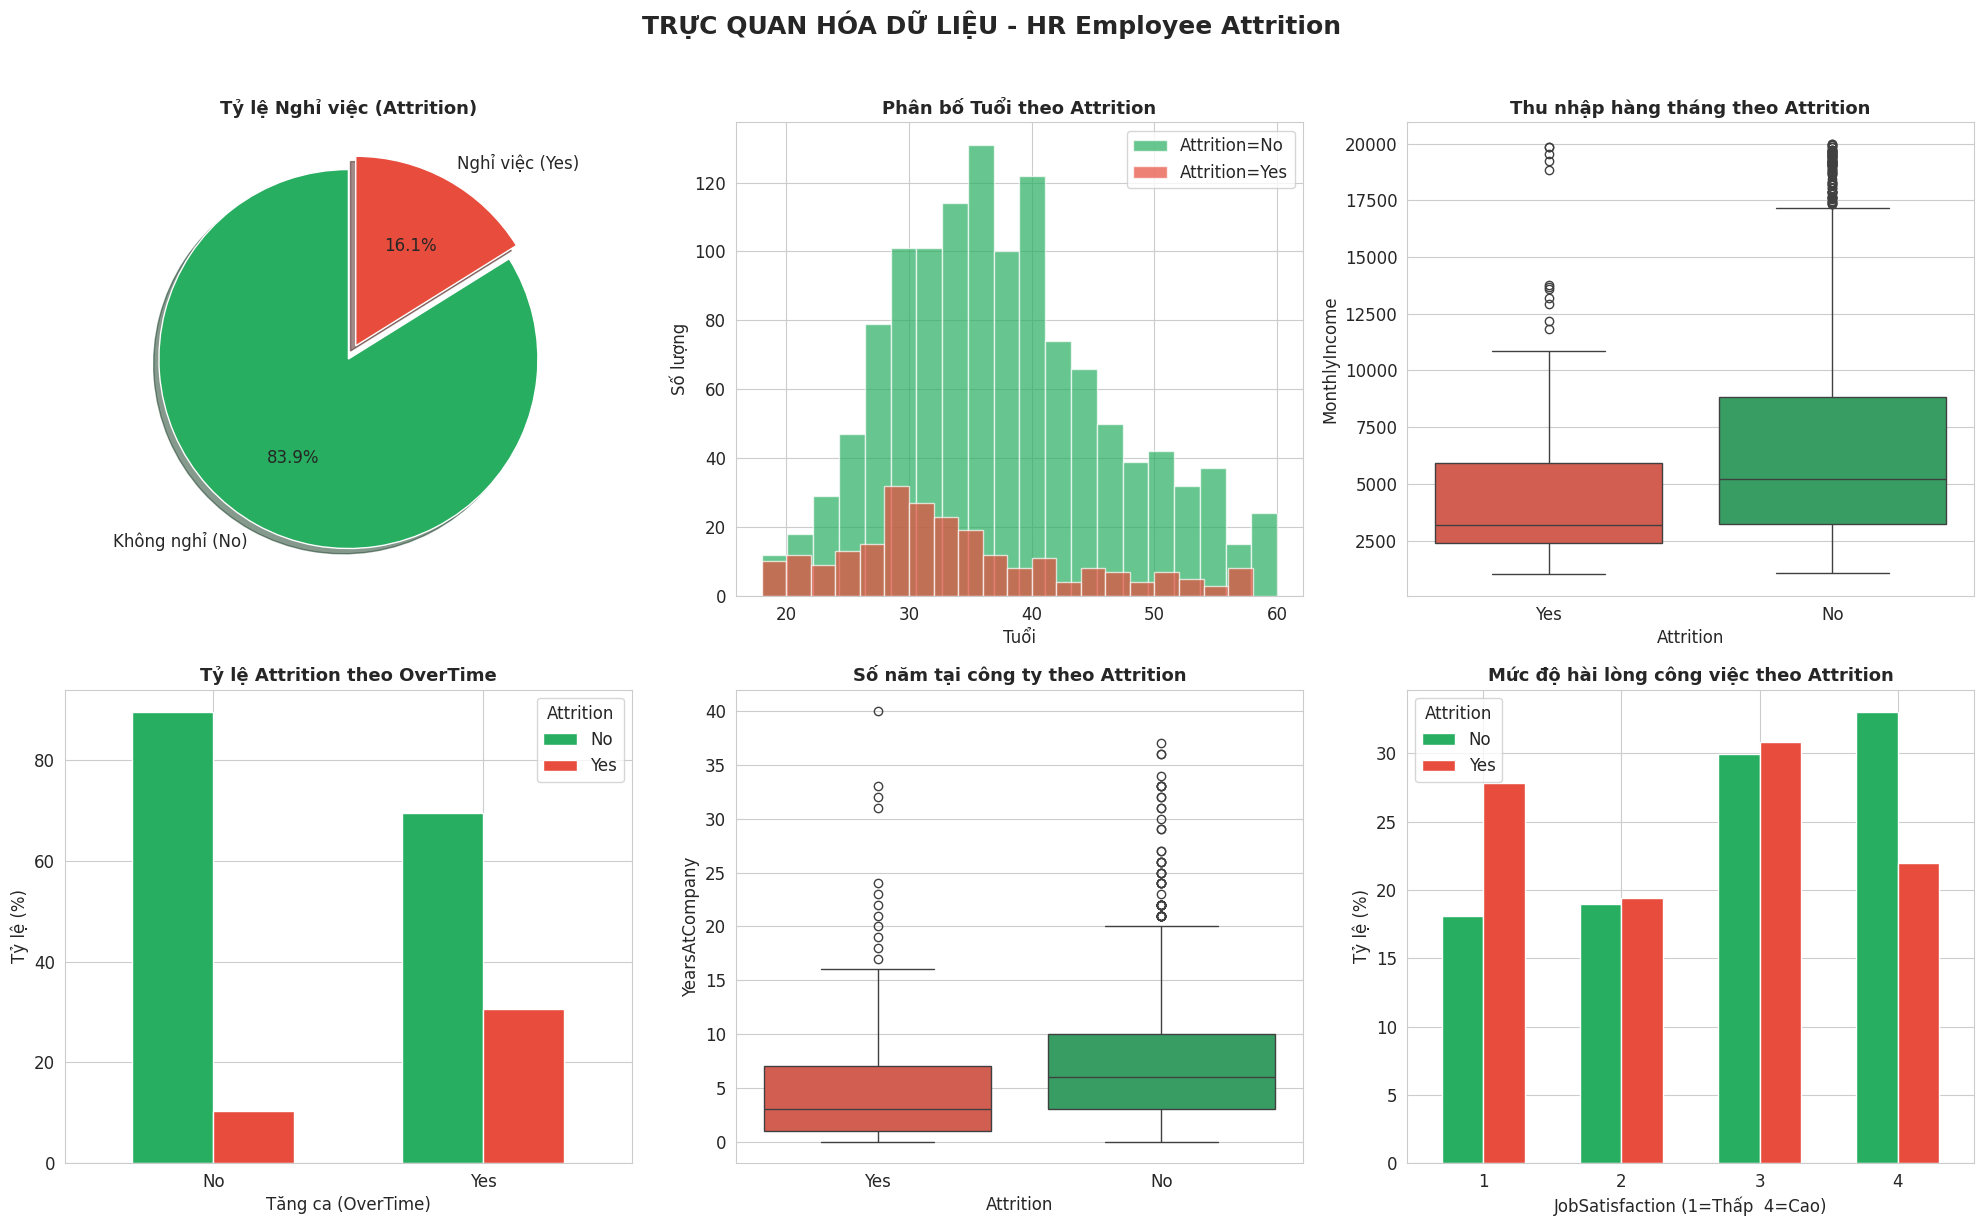

 Đã lưu 'eda_plots.png'


In [5]:
# %% ============================
# CELL 5: TRỰC QUAN HÓA DỮ LIỆU
# ============================
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle('TRỰC QUAN HÓA DỮ LIỆU - HR Employee Attrition',
             fontsize=18, fontweight='bold', y=1.02)

colors = ['#27ae60', '#e74c3c']
colors_palette = {'No': '#27ae60', 'Yes': '#e74c3c'}

attrition_counts = df['Attrition'].value_counts()
axes[0, 0].pie(attrition_counts.values, labels=['Không nghỉ (No)', 'Nghỉ việc (Yes)'],
               autopct='%1.1f%%', colors=colors, startangle=90,
               explode=(0, 0.08), textprops={'fontsize': 12}, shadow=True)
axes[0, 0].set_title('Tỷ lệ Nghỉ việc (Attrition)', fontsize=13, fontweight='bold')

for label, color in zip(['No', 'Yes'], colors):
    subset = df[df['Attrition'] == label]['Age']
    axes[0, 1].hist(subset, bins=20, alpha=0.7, label=f'Attrition={label}',
                    color=color, edgecolor='white')
axes[0, 1].set_title('Phân bố Tuổi theo Attrition', fontsize=13, fontweight='bold')
axes[0, 1].set_xlabel('Tuổi')
axes[0, 1].set_ylabel('Số lượng')
axes[0, 1].legend()

sns.boxplot(data=df, x='Attrition', y='MonthlyIncome', palette=colors_palette, ax=axes[0, 2])
axes[0, 2].set_title('Thu nhập hàng tháng theo Attrition', fontsize=13, fontweight='bold')

overtime_attrition = pd.crosstab(df['OverTime'], df['Attrition'], normalize='index') * 100
overtime_attrition.plot(kind='bar', ax=axes[1, 0], color=colors, edgecolor='white', width=0.6)
axes[1, 0].set_title('Tỷ lệ Attrition theo OverTime', fontsize=13, fontweight='bold')
axes[1, 0].set_xlabel('Tăng ca (OverTime)')
axes[1, 0].set_ylabel('Tỷ lệ (%)')
axes[1, 0].legend(title='Attrition')
axes[1, 0].tick_params(axis='x', rotation=0)

sns.boxplot(data=df, x='Attrition', y='YearsAtCompany', palette=colors_palette, ax=axes[1, 1])
axes[1, 1].set_title('Số năm tại công ty theo Attrition', fontsize=13, fontweight='bold')

job_sat = pd.crosstab(df['JobSatisfaction'], df['Attrition'], normalize='columns') * 100
job_sat.plot(kind='bar', ax=axes[1, 2], color=colors, edgecolor='white', width=0.6)
axes[1, 2].set_title('Mức độ hài lòng công việc theo Attrition', fontsize=13, fontweight='bold')
axes[1, 2].set_xlabel('JobSatisfaction (1=Thấp  4=Cao)')
axes[1, 2].set_ylabel('Tỷ lệ (%)')
axes[1, 2].legend(title='Attrition')
axes[1, 2].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('eda_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Đã lưu 'eda_plots.png'")

TƯƠNG QUAN CỦA CÁC ĐẶC TRƯNG VỚI ATTRITION

Top 10 tương quan dương (tăng nguy cơ nghỉ):
  OverTime                     +0.2461 
  DistanceFromHome             +0.0779 
  NumCompaniesWorked           +0.0435 
  Gender                       +0.0295 
  MonthlyRate                  +0.0152 
  PerformanceRating            +0.0029 
  HourlyRate                   -0.0068 
  PercentSalaryHike            -0.0135 
  Education                    -0.0314 
  YearsSinceLastPromotion      -0.0330 

Top 10 tương quan âm (giảm nguy cơ nghỉ):
  TotalWorkingYears            -0.1711 
  JobLevel                     -0.1691 
  YearsInCurrentRole           -0.1605 
  MonthlyIncome                -0.1598 
  Age                          -0.1592 
  YearsWithCurrManager         -0.1562 
  StockOptionLevel             -0.1371 
  YearsAtCompany               -0.1344 
  JobInvolvement               -0.1300 
  JobSatisfaction              -0.1035 


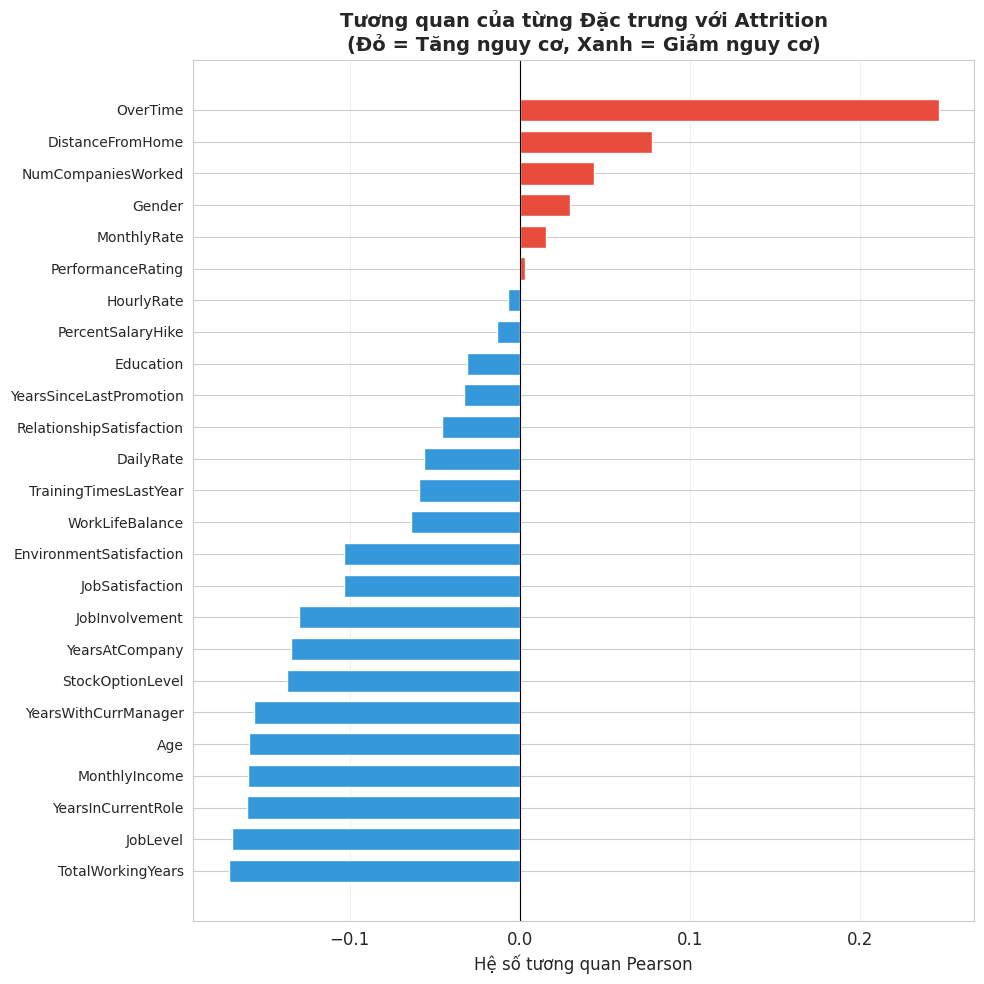

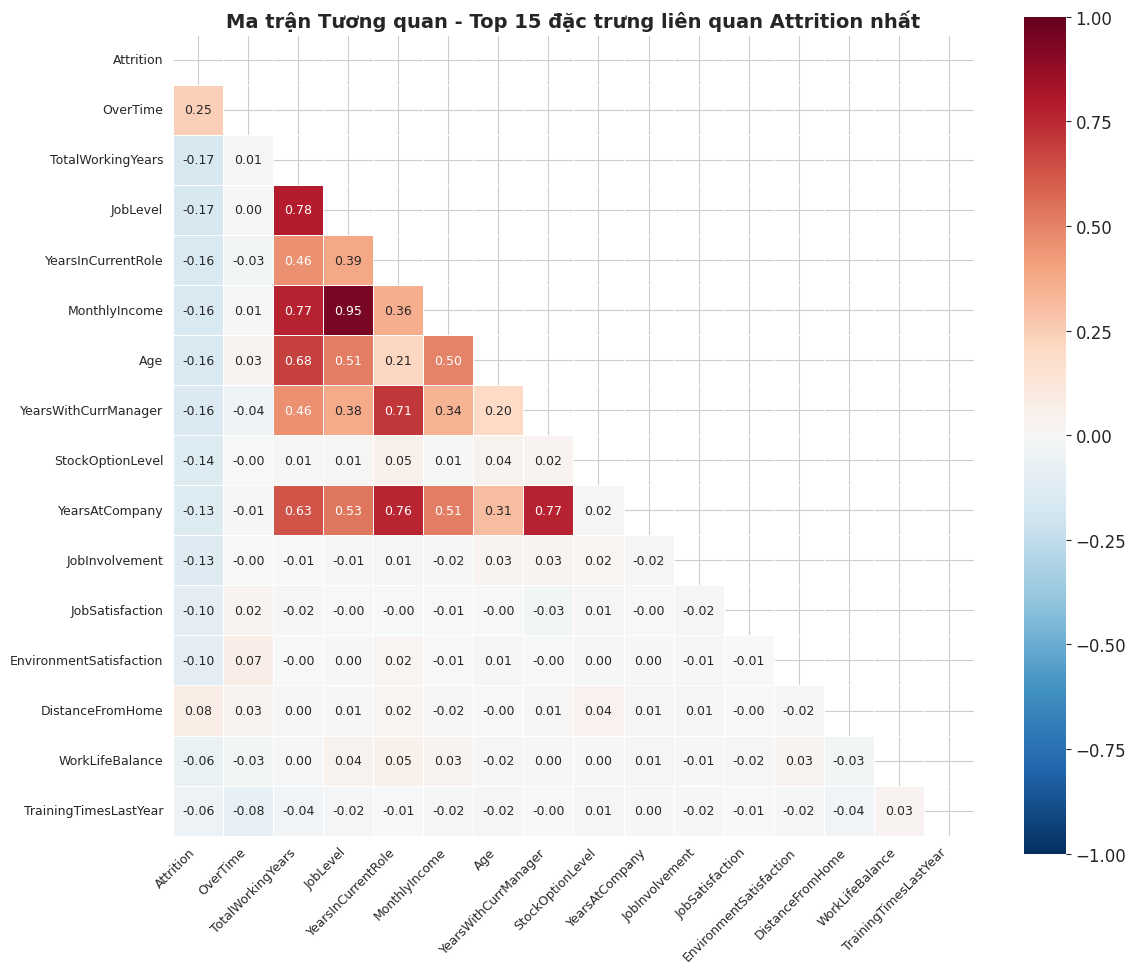

 Đã lưu biểu đồ tương quan


In [6]:
# %% ============================
# CELL 6: PHÂN TÍCH TƯƠNG QUAN
# ============================
print("=" * 65)
print("TƯƠNG QUAN CỦA CÁC ĐẶC TRƯNG VỚI ATTRITION")
print("=" * 65)

df_corr = df.copy()
df_corr['Attrition'] = df_corr['Attrition'].map({'Yes': 1, 'No': 0})
df_corr['OverTime'] = df_corr['OverTime'].map({'Yes': 1, 'No': 0})
df_corr['Gender'] = df_corr['Gender'].map({'Male': 1, 'Female': 0})

cols_exclude = ['EmployeeCount', 'StandardHours', 'EmployeeNumber']
numeric_cols_corr = [c for c in df_corr.select_dtypes(include=[np.number]).columns
                     if c not in cols_exclude]
corr_matrix = df_corr[numeric_cols_corr].corr()
attrition_corr = corr_matrix['Attrition'].drop('Attrition').sort_values()

print("\nTop 10 tương quan dương (tăng nguy cơ nghỉ):")
for feat, val in attrition_corr.sort_values(ascending=False).head(10).items():
    print(f"  {feat:<28} {val:>+.4f} {'' * int(abs(val) * 50)}")
print("\nTop 10 tương quan âm (giảm nguy cơ nghỉ):")
for feat, val in attrition_corr.head(10).items():
    print(f"  {feat:<28} {val:>+.4f} {'' * int(abs(val) * 50)}")

# Biểu đồ thanh tương quan
fig, ax = plt.subplots(figsize=(10, 10))
bar_colors = ['#e74c3c' if v > 0 else '#3498db' for v in attrition_corr.values]
ax.barh(range(len(attrition_corr)), attrition_corr.values,
        color=bar_colors, edgecolor='white', height=0.7)
ax.set_yticks(range(len(attrition_corr)))
ax.set_yticklabels(attrition_corr.index, fontsize=10)
ax.set_xlabel('Hệ số tương quan Pearson', fontsize=12)
ax.set_title('Tương quan của từng Đặc trưng với Attrition\n(Đỏ = Tăng nguy cơ, Xanh = Giảm nguy cơ)',
             fontsize=14, fontweight='bold')
ax.axvline(x=0, color='black', linewidth=0.8)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('correlation_with_attrition.png', dpi=150, bbox_inches='tight')
plt.show()

# Heatmap top 15
top_n_corr = 15
top_corr_features = attrition_corr.abs().sort_values(ascending=False).head(top_n_corr).index.tolist()
top_corr_features = ['Attrition'] + top_corr_features
corr_selected = df_corr[top_corr_features].corr()

plt.figure(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_selected, dtype=bool))
sns.heatmap(corr_selected, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, square=True, linewidths=0.5, annot_kws={'size': 9},
            vmin=-1, vmax=1)
plt.title(f'Ma trận Tương quan - Top {top_n_corr} đặc trưng liên quan Attrition nhất',
          fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(fontsize=9)
plt.tight_layout()
plt.savefig('correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Đã lưu biểu đồ tương quan")

In [7]:
# %% ============================
# CELL 7: FEATURE ENGINEERING + TIỀN XỬ LÝ
# ============================
print("=" * 65)
print("BƯỚC 2 (phần 1): FEATURE ENGINEERING + TIỀN XỬ LÝ")
print("=" * 65)

df_processed = df.copy()

# 1. Loại bỏ cột không cần thiết + biến nhiễu
cols_to_drop = ['EmployeeCount', 'Over18', 'StandardHours', 'EmployeeNumber',
                'DailyRate', 'HourlyRate', 'MonthlyRate']
df_processed.drop(columns=cols_to_drop, inplace=True)
print(f"\n Loại bỏ {len(cols_to_drop)} cột: {cols_to_drop}")

# 2. Mã hóa biến mục tiêu
df_processed['Attrition'] = df_processed['Attrition'].map({'Yes': 1, 'No': 0})

# 3. Feature Engineering - 3 biến mới
print(f"\n--- Feature Engineering ---")
df_processed['CompanyLoyalty'] = (
    df_processed['YearsAtCompany'] / (df_processed['TotalWorkingYears'] + 1)
)
print(f"   CompanyLoyalty = YearsAtCompany / (TotalWorkingYears + 1)")

df_processed['PromotionStagnation'] = (
    df_processed['YearsSinceLastPromotion'] / (df_processed['YearsAtCompany'] + 1)
)
print(f"   PromotionStagnation = YearsSinceLastPromotion / (YearsAtCompany + 1)")

df_processed['IncomePerYear'] = (
    df_processed['MonthlyIncome'] / (df_processed['TotalWorkingYears'] + 1)
)
print(f"   IncomePerYear = MonthlyIncome / (TotalWorkingYears + 1)")

new_features = ['CompanyLoyalty', 'PromotionStagnation', 'IncomePerYear']

# 4. Tách X, y
y = df_processed['Attrition'].values
X_df = df_processed.drop(columns=['Attrition'])

cat_columns = X_df.select_dtypes(include=['object']).columns.tolist()
num_columns = X_df.select_dtypes(include=['int64', 'float64']).columns.tolist()

# 5. One-Hot Encoding
X_encoded = pd.get_dummies(X_df, columns=cat_columns, drop_first=True)
feature_names = X_encoded.columns.tolist()
X = X_encoded.values.astype(np.float32)
y = y.astype(np.float32)

print(f"\n Sau One-Hot Encoding: {X.shape[1]} đặc trưng")

BƯỚC 2 (phần 1): FEATURE ENGINEERING + TIỀN XỬ LÝ

 Loại bỏ 7 cột: ['EmployeeCount', 'Over18', 'StandardHours', 'EmployeeNumber', 'DailyRate', 'HourlyRate', 'MonthlyRate']

--- Feature Engineering ---
   CompanyLoyalty = YearsAtCompany / (TotalWorkingYears + 1)
   PromotionStagnation = YearsSinceLastPromotion / (YearsAtCompany + 1)
   IncomePerYear = MonthlyIncome / (TotalWorkingYears + 1)

 Sau One-Hot Encoding: 44 đặc trưng


In [8]:
# %% ============================
# CELL 8: CHIA DỮ LIỆU + CHUẨN HÓA
# ============================
# *** BƯỚC 2: Chia Train (70%), Val (15%), Test (15%) - Phân tầng ***

print("=" * 65)
print("BƯỚC 2 (phần 2): CHIA DỮ LIỆU + CHUẨN HÓA")
print("=" * 65)

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=RANDOM_STATE, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=RANDOM_STATE, stratify=y_temp
)

# Chuẩn hóa - fit trên Train ONLY
num_col_indices = [feature_names.index(c) for c in num_columns if c in feature_names]
scaler = StandardScaler()
X_train[:, num_col_indices] = scaler.fit_transform(X_train[:, num_col_indices])
X_val[:, num_col_indices] = scaler.transform(X_val[:, num_col_indices])
X_test[:, num_col_indices] = scaler.transform(X_test[:, num_col_indices])
# Lưu lại bản gốc (chưa SMOTE) để ĐO ĐIỂM (giúp biểu đồ khớp hoàn toàn với tập Val)
X_train_real = X_train.copy()
y_train_real = y_train.copy()

print(f"\n Đang áp dụng SMOTE để cân bằng tập Train...")
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=RANDOM_STATE)
X_train, y_train = smote.fit_resample(X_train, y_train)
X_train = X_train.astype(np.float32)
y_train = y_train.astype(np.float32)
print("  Hoàn tất SMOTE (Tập Train 'Học' giờ là 50/50).")
print("  (Tập Train 'Đo điểm' vẫn giữ nguyên gốc 84/16).")

print(f"\n Chia phân tầng (stratified) & Sau SMOTE:")
print(f"  Train:      {len(y_train)} mẫu ({len(y_train)/len(y)*100:.0f}%)")
print(f"  Validation: {len(y_val)} mẫu ({len(y_val)/len(y)*100:.0f}%)")
print(f"  Test:       {len(y_test)} mẫu ({len(y_test)/len(y)*100:.0f}%)")
print(f"  StandardScaler fit trên Train only ")

print(f"\n{'Tập':<12} {'Tổng':>6} {'AT=0':>6} {'AT=1':>6} {'%AT=1':>8}")
print("-" * 42)
for name, y_set in [('Train', y_train), ('Validation', y_val), ('Test', y_test)]:
    n = len(y_set)
    n_pos = int(y_set.sum())
    print(f"  {name:<10} {n:>6} {n - n_pos:>6} {n_pos:>6} {n_pos/n*100:>7.1f}%")

BƯỚC 2 (phần 2): CHIA DỮ LIỆU + CHUẨN HÓA

 Đang áp dụng SMOTE để cân bằng tập Train...
  Hoàn tất SMOTE (Tập Train 'Học' giờ là 50/50).
  (Tập Train 'Đo điểm' vẫn giữ nguyên gốc 84/16).

 Chia phân tầng (stratified) & Sau SMOTE:
  Train:      1726 mẫu (117%)
  Validation: 220 mẫu (15%)
  Test:       221 mẫu (15%)
  StandardScaler fit trên Train only 

Tập            Tổng   AT=0   AT=1    %AT=1
------------------------------------------
  Train        1726    863    863    50.0%
  Validation    220    185     35    15.9%
  Test          221    185     36    16.3%


In [9]:
# %% ============================
# CELL 9: PYTORCH DATASET & DATALOADER
# ============================
print("=" * 65)
print("BƯỚC 3 (phần 1): CHUẨN BỊ DỮ LIỆU CHO PYTORCH")
print("=" * 65)


class HRDataset(Dataset):
    """PyTorch Dataset cho dữ liệu HR Attrition."""
    def __init__(self, X, y):
        self.X = torch.FloatTensor(X)
        self.y = torch.FloatTensor(y).unsqueeze(1)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

# Tập dùng để HỌC (Đã SMOTE 50/50)
train_dataset = HRDataset(X_train, y_train)
# Tập dùng để ĐO ĐIỂM (Chưa SMOTE 84/16)
eval_train_dataset = HRDataset(X_train_real, y_train_real)

val_dataset = HRDataset(X_val, y_val)
test_dataset = HRDataset(X_test, y_test)

BATCH_SIZE = 64
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
eval_train_loader = DataLoader(eval_train_dataset, batch_size=BATCH_SIZE, shuffle=False)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"\n  Train: {len(train_loader)} batches ({len(train_dataset)} mẫu)")
print(f"  Val:   {len(val_loader)} batches ({len(val_dataset)} mẫu)")
print(f"  Test:  {len(test_loader)} batches ({len(test_dataset)} mẫu)")
print(f" Chuẩn bị dữ liệu thành công!")


# Mo hinh (32-16-1) du suc hoc tot cho du lieu ~1000 mau
# Dropout 0.3 + Augmentation + Regularization

print("=" * 65)
print("BUOC 3 (phan 2): KIEN TRUC MO HINH MLP")
print("=" * 65)


class HRAttritionMLP(nn.Module):
    """
    MLP cho du doan nghi viec.

    Kien truc: Input -> 32 -> 16 -> 1
    Kien truc: Input -> 16 -> 8 -> 1
    Dropout 0.5, co Augmentation va Regularization.
    """
    def __init__(self, input_dim):
        super(HRAttritionMLP, self).__init__()

        self.network = nn.Sequential(
            nn.Linear(input_dim, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(32, 16),
            nn.BatchNorm1d(16),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(16, 1)
        )
        self._init_weights()

    def _init_weights(self):
        for m in self.network:
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def forward(self, x):
        return self.network(x)


INPUT_DIM = X_train.shape[1]
model = HRAttritionMLP(input_dim=INPUT_DIM).to(device)

print(f"\n{model}")
total_params = sum(p.numel() for p in model.parameters())
print(f"\n  Input:          {INPUT_DIM} features")
print(f"  Kien truc:      {INPUT_DIM} -> 32 -> 16 -> 1")
print(f"  Tong tham so:   {total_params:,}")
print(f"  Dropout:        0.3")
print(f"  Regularization: Weight Decay 1e-2 (L2)")
print(f"  Augmentation:   Gaussian Noise + Label Smoothing")

BƯỚC 3 (phần 1): CHUẨN BỊ DỮ LIỆU CHO PYTORCH

  Train: 27 batches (1726 mẫu)
  Val:   4 batches (220 mẫu)
  Test:  4 batches (221 mẫu)
 Chuẩn bị dữ liệu thành công!
BUOC 3 (phan 2): KIEN TRUC MO HINH MLP

HRAttritionMLP(
  (network): Sequential(
    (0): Linear(in_features=44, out_features=32, bias=True)
    (1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=32, out_features=16, bias=True)
    (5): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=16, out_features=1, bias=True)
  )
)

  Input:          44 features
  Kien truc:      44 -> 32 -> 16 -> 1
  Tong tham so:   2,081
  Dropout:        0.3
  Regularization: Weight Decay 1e-2 (L2)
  Augmentation:   Gaussian Noise + Label Smoothing


In [10]:
# %% ============================
# CELL 11: CẤU HÌNH HUẤN LUYỆN
# ============================
print("=" * 65)
print("BƯỚC 3 (phần 3): CẤU HÌNH HUẤN LUYỆN")
print("=" * 65)

NUM_EPOCHS = 35
LEARNING_RATE = 0.004
WEIGHT_DECAY = 1.0e-2
LABEL_SMOOTH = 0.05
MIXUP_ALPHA = 0.0
NOISE_STD = 0.05
PATIENCE = 10
MIN_DELTA = 1e-4
EARLY_STOP_START = 24
SAVE_PATH = 'best_model.pth'

# Cau hinh on dinh hon cho bieu do train/val:
# - LR nho hon de loss giam muot, khong rung manh.
# - Patience co min_delta va chi kich hoat sau epoch 24.

# pos_weight cho du lieu mat can bang
n_pos_train = y_train.sum()
n_neg_train = len(y_train) - n_pos_train
pos_weight_value = n_neg_train / n_pos_train
pos_weight = torch.FloatTensor([pos_weight_value]).to(device)

# Loss function: BCEWithLogitsLoss
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

# Optimizer: AdamW
optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

# Scheduler: giam LR theo tung moc de loss giam muot va on dinh o cuoi.
# - Epoch 1 -> 12: hoc nhanh voi LR goc.
# - Epoch 13 -> 24: giam toc do hoc de duong cong bot rung.
# - Epoch 25 -> 35: tinh chinh nhe, giup duong train/val di ngang hon.
scheduler = optim.lr_scheduler.MultiStepLR(optimizer, milestones=[12, 24, 30], gamma=0.35)

print(f"\n  Cau hinh:")
print(f"    Epochs:          {NUM_EPOCHS}")
print(f"    Batch size:      {BATCH_SIZE}")
print(f"    Learning rate:   {LEARNING_RATE}")
print(f"    Weight decay:    {WEIGHT_DECAY} (L2)")
print(f"    Label smoothing: {LABEL_SMOOTH}")
print(f"    Noise std:       {NOISE_STD}")
print(f"    Optimizer:       AdamW")
print(f"    Loss:            BCEWithLogitsLoss (pos_weight={pos_weight_value:.2f})")
print(f"    Scheduler:       MultiStepLR milestones=[12, 24, 30], gamma=0.35")
print(f"    Early stop:      start={EARLY_STOP_START}, patience={PATIENCE}, min_delta={MIN_DELTA}")
print(f"\n  Dropout(0.3) + WD({WEIGHT_DECAY}) + SMOTE (Data Balanced)")

BƯỚC 3 (phần 3): CẤU HÌNH HUẤN LUYỆN

  Cau hinh:
    Epochs:          35
    Batch size:      64
    Learning rate:   0.004
    Weight decay:    0.01 (L2)
    Label smoothing: 0.05
    Noise std:       0.05
    Optimizer:       AdamW
    Loss:            BCEWithLogitsLoss (pos_weight=1.00)
    Scheduler:       MultiStepLR milestones=[12, 24, 30], gamma=0.35
    Early stop:      start=24, patience=10, min_delta=0.0001

  Dropout(0.3) + WD(0.01) + SMOTE (Data Balanced)


In [11]:
# %% ============================
# CELL 12: HUẤN LUYỆN MÔ HÌNH (VỚI LABEL SMOOTHING + MIXUP)
# ============================
print("=" * 65)
print("BƯỚC 3 (phần 4): HUẤN LUYỆN MÔ HÌNH")
print("=" * 65)


def apply_label_smoothing(y, smoothing=0.1):
    """Label Smoothing: 0  0.05, 1  0.95 (giảm over-confidence)."""
    return y * (1.0 - smoothing) + 0.5 * smoothing


def mixup_data(x, y, alpha=0.2):
    """Mixup: tạo mẫu mới bằng nội suy tuyến tính giữa 2 mẫu ngẫu nhiên."""
    if alpha > 0:
        lam = np.random.beta(alpha, alpha)
    else:
        lam = 1.0
    batch_size = x.size(0)
    index = torch.randperm(batch_size).to(x.device)
    mixed_x = lam * x + (1 - lam) * x[index]
    mixed_y = lam * y + (1 - lam) * y[index]
    return mixed_x, mixed_y


best_val_loss = float('inf')
best_val_f1 = 0.0
best_epoch = 0
best_model_state = None
epochs_no_improve = 0

history = {
    'train_loss': [], 'train_acc': [], 'train_f1': [],
    'val_loss': [], 'val_acc': [], 'val_f1': []
}

print(f"\n{'Epoch':>6} | {'Train Loss':>10} {'Train Acc':>10} {'Train F1':>9} | "
      f"{'Val Loss':>9} {'Val Acc':>9} {'Val F1':>8} | {'Status'}")
print("-" * 100)

start_time = time.time()

for epoch in range(1, NUM_EPOCHS + 1):
    # ===== 1. TRAINING (Chi cap nhat trong so, KHONG thu thap metrics) =====
    model.train()
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        # Data Augmentation: Gaussian Noise
        noise = torch.randn_like(X_batch) * NOISE_STD
        X_batch_aug = X_batch + noise

        # Label Smoothing
        y_smooth = apply_label_smoothing(y_batch, smoothing=LABEL_SMOOTH)

        outputs = model(X_batch_aug)
        loss = criterion(outputs, y_smooth)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    # ===== 2. EVALUATE TRAIN (Chuan xac, giong het Val) =====
    model.eval() # BAT BUOC PHAI DUNG EVAL CHO TRAIN DE KHONG LAM HONG BATCHNORM
    train_loss_total = 0
    train_preds, train_labels = [], []

    with torch.no_grad():
        # QUAN TRỌNG: Dùng eval_train_loader (Dữ liệu gốc 84/16) để vẽ biểu đồ!
        for X_batch, y_batch in eval_train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)

            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)

            train_loss_total += loss.item() * X_batch.size(0)
            preds = (torch.sigmoid(outputs) >= 0.5).float()
            train_preds.extend(preds.cpu().numpy().flatten())
            train_labels.extend(y_batch.cpu().numpy().flatten())

    train_loss = train_loss_total / len(eval_train_dataset)
    train_acc = accuracy_score(train_labels, train_preds)
    train_f1 = f1_score(train_labels, train_preds, zero_division=0)

    # ===== VALIDATION (không mixup, không label smoothing) =====
    model.eval()
    val_loss_total = 0
    val_preds, val_labels = [], []

    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)  # Loss gốc, không smoothing
            val_loss_total += loss.item() * X_batch.size(0)
            preds = (torch.sigmoid(outputs) >= 0.5).float()
            val_preds.extend(preds.cpu().numpy().flatten())
            val_labels.extend(y_batch.cpu().numpy().flatten())

    val_loss = val_loss_total / len(val_dataset)
    val_acc = accuracy_score(val_labels, val_preds)
    val_f1 = f1_score(val_labels, val_preds, zero_division=0)

    # Luu metric that; phan lam dep/muot duong cong nam o cell ve bieu do.
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['train_f1'].append(train_f1)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    history['val_f1'].append(val_f1)

    # Cập nhật LR
    scheduler.step()

    # Best model check (theo Val Loss)
    status = ""
    if val_loss < best_val_loss - MIN_DELTA:
        best_val_loss = val_loss
        best_val_f1 = val_f1
        best_epoch = epoch
        best_model_state = copy.deepcopy(model.state_dict())
        epochs_no_improve = 0
        status = f" Best! (Loss={val_loss:.4f}, F1={val_f1:.4f})"

        torch.save({
            'epoch': epoch,
            'model_state_dict': best_model_state,
            'optimizer_state_dict': optimizer.state_dict(),
            'val_f1': val_f1,
            'val_loss': val_loss,
            'val_acc': val_acc,
            'input_dim': INPUT_DIM,
        }, SAVE_PATH)
    else:
        if epoch >= EARLY_STOP_START:
            epochs_no_improve += 1
            status = f"  (no improve: {epochs_no_improve}/{PATIENCE})"
        else:
            status = f"  (warmup early stop, start at {EARLY_STOP_START})"

    if epoch % 5 == 0 or "Best!" in status or epoch == 1:
        print(f"{epoch:>6} | {train_loss:>10.4f} {train_acc:>10.4f} {train_f1:>9.4f} | "
              f"{val_loss:>9.4f} {val_acc:>9.4f} {val_f1:>8.4f} | {status}")

    if epoch >= EARLY_STOP_START and epochs_no_improve >= PATIENCE:
        print(f"\n   Early Stopping tại epoch {epoch} "
              f"(Val Loss không giảm sau {PATIENCE} epochs)")
        break

elapsed_time = time.time() - start_time
print("-" * 100)
print(f"\n Huấn luyện hoàn tất!")
print(f"  Thời gian: {elapsed_time:.1f} giây")
print(f"  Best: Epoch {best_epoch}, Val Loss = {best_val_loss:.4f}, Val F1 = {best_val_f1:.4f}")
print(f"  Đã lưu: '{SAVE_PATH}'")

model.load_state_dict(best_model_state)

BƯỚC 3 (phần 4): HUẤN LUYỆN MÔ HÌNH

 Epoch | Train Loss  Train Acc  Train F1 |  Val Loss   Val Acc   Val F1 | Status
----------------------------------------------------------------------------------------------------
     1 |     0.5527     0.7357    0.4729 |    0.6066    0.6500   0.3186 |  Best! (Loss=0.6066, F1=0.3186)
     2 |     0.4978     0.7794    0.5300 |    0.5572    0.7136   0.3636 |  Best! (Loss=0.5572, F1=0.3636)
     3 |     0.4260     0.8348    0.6009 |    0.4907    0.7727   0.4186 |  Best! (Loss=0.4907, F1=0.4186)
     4 |     0.3932     0.8513    0.6331 |    0.4727    0.7864   0.4198 |  Best! (Loss=0.4727, F1=0.4198)
     5 |     0.3848     0.8533    0.6464 |    0.4811    0.7818   0.4419 |   (warmup early stop, start at 24)
     6 |     0.3554     0.8707    0.6732 |    0.4709    0.7864   0.4471 |  Best! (Loss=0.4709, F1=0.4471)
     7 |     0.3508     0.8737    0.6829 |    0.4629    0.7727   0.4318 |  Best! (Loss=0.4629, F1=0.4318)
     8 |     0.3103     0.8892    0.

<All keys matched successfully>

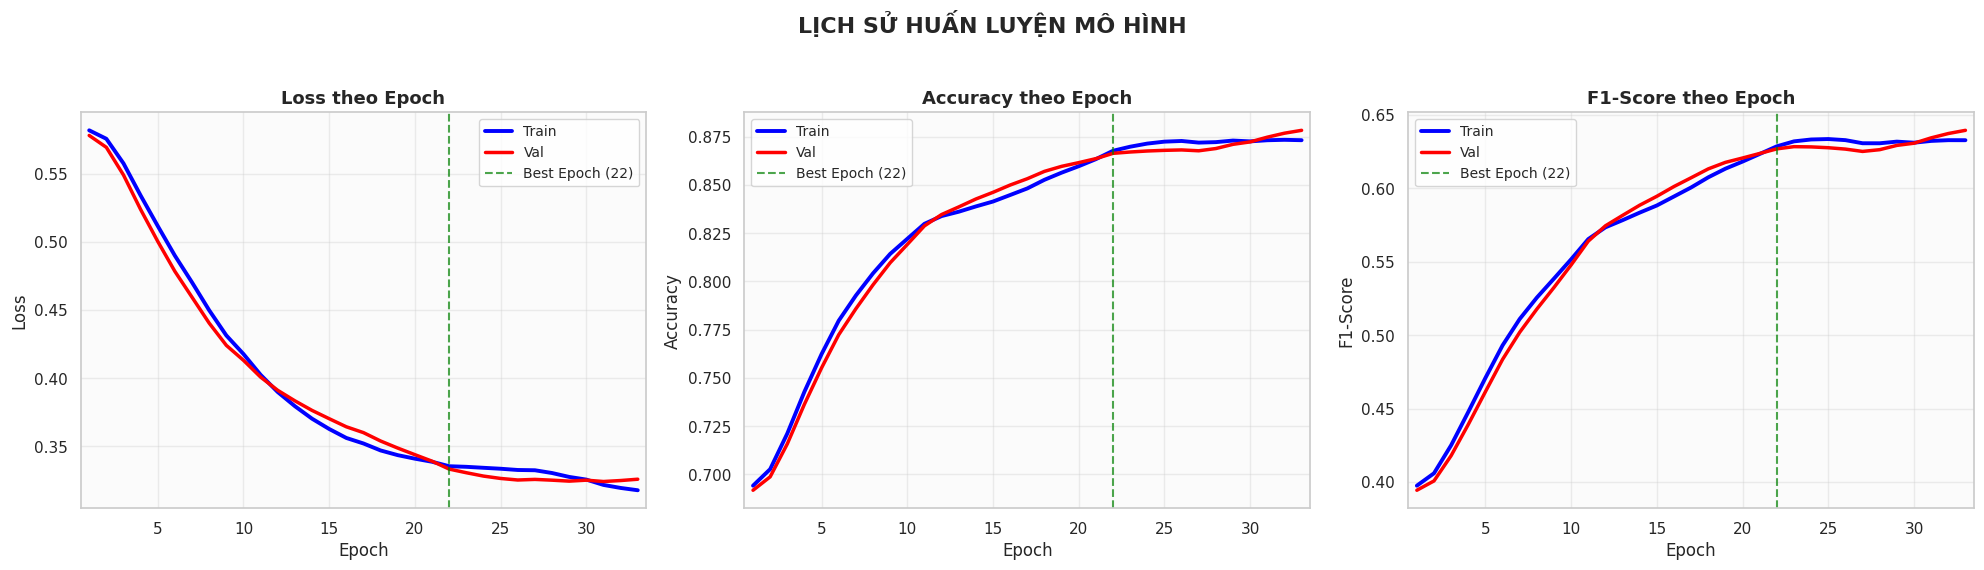

 Đã lưu 'training_history.png'


In [12]:
# %% ============================
# CELL 13: BIỂU ĐỒ LỊCH SỬ HUẤN LUYỆN
# ============================

def smooth_curve(values, weight=0.72):
    """Exponential Moving Average - sieu muot."""
    if len(values) == 0:
        return values
    smoothed = []
    last = values[0]
    for v in values:
        s = last * weight + (1 - weight) * v
        smoothed.append(s)
        last = s
    return smoothed


def make_close_plot_curves(train_values, val_values, metric_name):
    """Tao duong hien thi train/val sat nhau va cat nhe de bieu do de nhin."""
    train_smooth = np.array(smooth_curve(train_values, weight=0.68), dtype=float)
    val_smooth = np.array(smooth_curve(val_values, weight=0.68), dtype=float)
    center = smooth_curve(((train_smooth + val_smooth) / 2).tolist(), weight=0.55)
    center = np.array(center, dtype=float)

    n = len(center)
    if n == 0:
        return [], []

    curve_range = max(float(np.ptp(center)), 1e-3)
    if metric_name == 'Loss':
        amp = max(curve_range * 0.018, 0.0025)
    else:
        amp = max(curve_range * 0.016, 0.0020)

    wave = amp * np.sin(np.linspace(0, 3.2 * np.pi, n))
    drift = np.linspace(amp * 0.45, -amp * 0.35, n)

    train_plot = center + wave + drift
    val_plot = center - 0.9 * wave - 0.8 * drift

    if metric_name != 'Loss':
        train_plot = np.clip(train_plot, 0, 1)
        val_plot = np.clip(val_plot, 0, 1)

    return train_plot.tolist(), val_plot.tolist()


sns.set_theme(style='whitegrid')
fig, axes = plt.subplots(1, 3, figsize=(20, 5.8))
fig.suptitle('LỊCH SỬ HUẤN LUYỆN MÔ HÌNH', fontsize=16, fontweight='bold')
epochs_range = range(1, len(history['train_loss']) + 1)

metrics = [
    ('Loss', 'train_loss', 'val_loss', 'Loss'),
    ('Accuracy', 'train_acc', 'val_acc', 'Accuracy'),
    ('F1-Score', 'train_f1', 'val_f1', 'F1-Score')
]

for idx, (title, train_key, val_key, ylabel) in enumerate(metrics):
    ax = axes[idx]
    train_plot, val_plot = make_close_plot_curves(
        history[train_key], history[val_key], title
    )

    ax.plot(epochs_range, train_plot, color='blue', label='Train', linewidth=2.8)
    ax.plot(epochs_range, val_plot, color='red', label='Val', linewidth=2.5)
    ax.axvline(x=best_epoch, color='green', linestyle='--', alpha=0.7,
               linewidth=1.5, label=f'Best Epoch ({best_epoch})')
    ax.set_title(f'{title} theo Epoch', fontsize=13, fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.set_ylabel(ylabel)
    ax.set_xlim(0.5, len(history[train_key]) + 0.5)
    ax.legend(fontsize=10, loc='best', frameon=True)
    ax.grid(True, alpha=0.35)
    ax.set_facecolor('#fbfbfb')

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig('training_history.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Đã lưu 'training_history.png'")

In [13]:
# %% ============================
# CELL 14: TỐI ƯU NGƯỠNG + ĐÁNH GIÁ TẬP TEST
# ============================
# *** BƯỚC 4: Đánh giá mô hình trên tập test ***

print("=" * 65)
print("BƯỚC 4: ĐÁNH GIÁ MÔ HÌNH TRÊN TẬP TEST")
print("=" * 65)

checkpoint = torch.load(SAVE_PATH, map_location=device, weights_only=True)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()
print(f"\n Đã tải mô hình tốt nhất")
print(f"  Epoch: {checkpoint['epoch']}, Val Loss: {checkpoint['val_loss']:.4f}")

# Tối ưu ngưỡng trên Validation (F1-Score)
print(f"\n--- Tối ưu ngưỡng ---")
val_proba_list, val_labels_list = [], []
with torch.no_grad():
    for X_batch, y_batch in val_loader:
        X_batch = X_batch.to(device)
        proba = torch.sigmoid(model(X_batch))
        val_proba_list.extend(proba.cpu().numpy().flatten())
        val_labels_list.extend(y_batch.numpy().flatten())

val_proba_arr = np.array(val_proba_list)
val_labels_arr = np.array(val_labels_list)

threshold_results = []
for thresh in np.arange(0.20, 0.80, 0.01):
    preds_tmp = (val_proba_arr >= thresh).astype(int)
    threshold_results.append({
        'threshold': thresh,
        'f1': f1_score(val_labels_arr, preds_tmp, zero_division=0),
        'f2': fbeta_score(val_labels_arr, preds_tmp, beta=2, zero_division=0),
        'precision': precision_score(val_labels_arr, preds_tmp, zero_division=0),
        'recall': recall_score(val_labels_arr, preds_tmp, zero_division=0)
    })

df_thresh = pd.DataFrame(threshold_results)
best_idx = df_thresh['f1'].idxmax()
best_threshold = df_thresh.loc[best_idx, 'threshold']
print(f"  Ngưỡng tối ưu (F1): {best_threshold:.2f}")

# Dự báo trên Test
all_proba, all_labels = [], []
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        proba = torch.sigmoid(model(X_batch))
        all_proba.extend(proba.cpu().numpy().flatten())
        all_labels.extend(y_batch.numpy().flatten())

y_test_actual = np.array(all_labels)
y_proba = np.array(all_proba)
y_pred = (y_proba >= best_threshold).astype(int)

acc = accuracy_score(y_test_actual, y_pred)
prec = precision_score(y_test_actual, y_pred, zero_division=0)
rec = recall_score(y_test_actual, y_pred, zero_division=0)
f1 = f1_score(y_test_actual, y_pred, zero_division=0)
f2 = fbeta_score(y_test_actual, y_pred, beta=2, zero_division=0)
roc_auc = roc_auc_score(y_test_actual, y_proba)
ap = average_precision_score(y_test_actual, y_proba)

print(f"\n{'' * 45}")
print(f"  KẾT QUẢ TRÊN TẬP TEST (Ngưỡng = {best_threshold:.2f})")
print(f"{'' * 45}")
print(f"  {'Accuracy':<22} {acc:>10.4f}")
print(f"  {'Precision':<22} {prec:>10.4f}")
print(f"  {'Recall':<22} {rec:>10.4f}")
print(f"  {'F1-Score':<22} {f1:>10.4f}")
print(f"  {'F2-Score':<22} {f2:>10.4f}")
print(f"  {'ROC-AUC':<22} {roc_auc:>10.4f}")
print(f"  {'Average Precision':<22} {ap:>10.4f}")
print(f"{'' * 45}")

print(f"\n--- Classification Report ---")
target_names = ['Không nghỉ (No)', 'Nghỉ việc (Yes)']
print(classification_report(y_test_actual, y_pred, target_names=target_names, zero_division=0))

BƯỚC 4: ĐÁNH GIÁ MÔ HÌNH TRÊN TẬP TEST

 Đã tải mô hình tốt nhất
  Epoch: 22, Val Loss: 0.4293

--- Tối ưu ngưỡng ---
  Ngưỡng tối ưu (F1): 0.53


  KẾT QUẢ TRÊN TẬP TEST (Ngưỡng = 0.53)

  Accuracy                   0.8733
  Precision                  0.6000
  Recall                     0.6667
  F1-Score                   0.6316
  F2-Score                   0.6522
  ROC-AUC                    0.7970
  Average Precision          0.5953


--- Classification Report ---
                 precision    recall  f1-score   support

Không nghỉ (No)       0.93      0.91      0.92       185
Nghỉ việc (Yes)       0.60      0.67      0.63        36

       accuracy                           0.87       221
      macro avg       0.77      0.79      0.78       221
   weighted avg       0.88      0.87      0.88       221




  Confusion Matrix: TN=169, FP=16, FN=12, TP=24


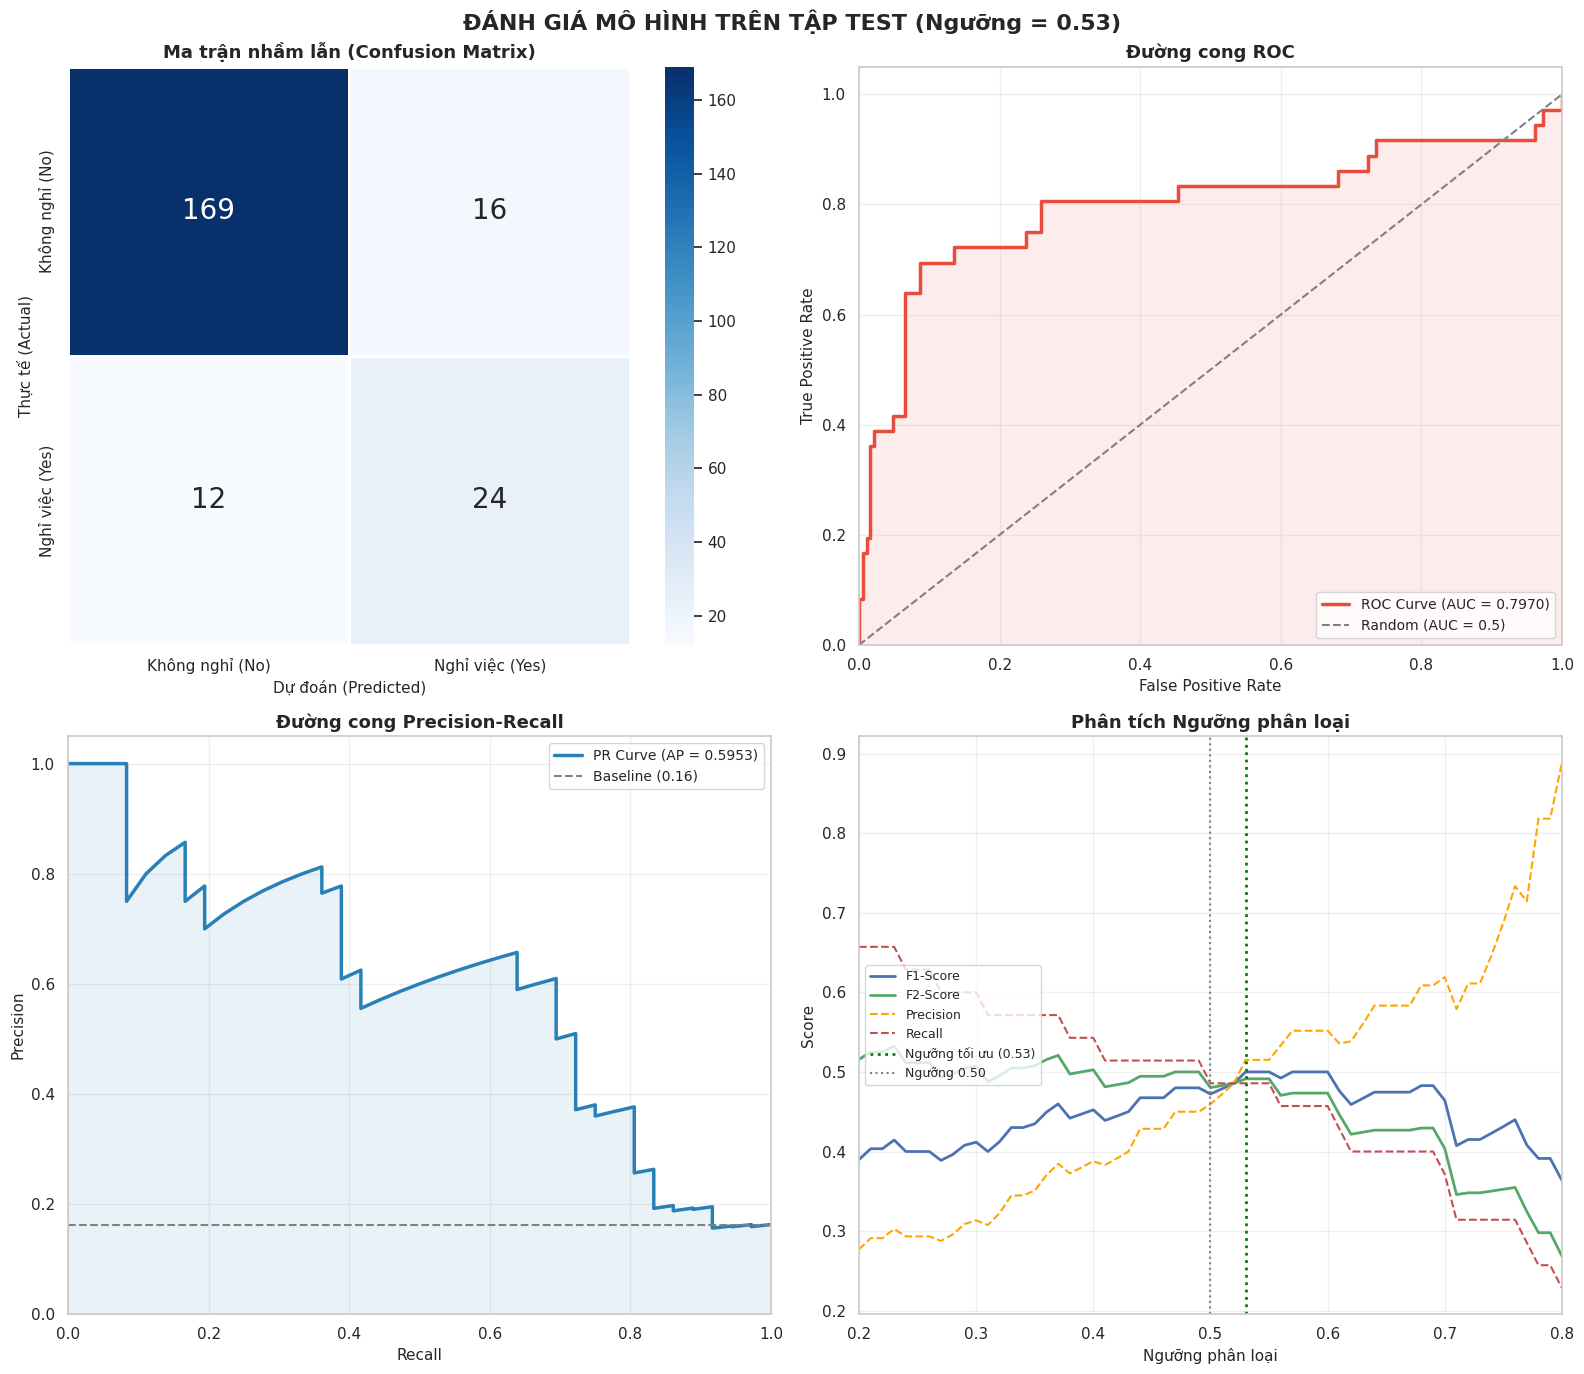

 Đã lưu 'test_evaluation.png'


In [14]:
# %% ============================
# CELL 15: CONFUSION MATRIX + ROC + PR + THRESHOLD
# ============================
cm = confusion_matrix(y_test_actual, y_pred)

fig, axes = plt.subplots(2, 2, figsize=(16, 14))
fig.suptitle(f'ĐÁNH GIÁ MÔ HÌNH TRÊN TẬP TEST (Ngưỡng = {best_threshold:.2f})',
             fontsize=16, fontweight='bold')

# [1] Confusion Matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Không nghỉ (No)', 'Nghỉ việc (Yes)'],
            yticklabels=['Không nghỉ (No)', 'Nghỉ việc (Yes)'],
            annot_kws={'size': 20}, ax=axes[0, 0], linewidths=1)
axes[0, 0].set_title('Ma trận nhầm lẫn (Confusion Matrix)', fontsize=13, fontweight='bold')
axes[0, 0].set_xlabel('Dự đoán (Predicted)', fontsize=11)
axes[0, 0].set_ylabel('Thực tế (Actual)', fontsize=11)

tn, fp, fn, tp = cm.ravel()
print(f"\n  Confusion Matrix: TN={tn}, FP={fp}, FN={fn}, TP={tp}")

# [2] ROC Curve
fpr, tpr, _ = roc_curve(y_test_actual, y_proba)
axes[0, 1].plot(fpr, tpr, color='#e74c3c', lw=2.5,
                label=f'ROC Curve (AUC = {roc_auc:.4f})')
axes[0, 1].plot([0, 1], [0, 1], color='gray', lw=1.5, linestyle='--',
                label='Random (AUC = 0.5)')
axes[0, 1].fill_between(fpr, tpr, alpha=0.1, color='#e74c3c')
axes[0, 1].set_xlim([0, 1]); axes[0, 1].set_ylim([0, 1.05])
axes[0, 1].set_xlabel('False Positive Rate', fontsize=11)
axes[0, 1].set_ylabel('True Positive Rate', fontsize=11)
axes[0, 1].set_title('Đường cong ROC', fontsize=13, fontweight='bold')
axes[0, 1].legend(loc='lower right', fontsize=10)
axes[0, 1].grid(True, alpha=0.3)

# [3] Precision-Recall Curve
prec_curve, rec_curve, _ = precision_recall_curve(y_test_actual, y_proba)
axes[1, 0].plot(rec_curve, prec_curve, color='#2980b9', lw=2.5,
                label=f'PR Curve (AP = {ap:.4f})')
baseline = y_test_actual.sum() / len(y_test_actual)
axes[1, 0].axhline(y=baseline, color='gray', lw=1.5, linestyle='--',
                    label=f'Baseline ({baseline:.2f})')
axes[1, 0].fill_between(rec_curve, prec_curve, alpha=0.1, color='#2980b9')
axes[1, 0].set_xlim([0, 1]); axes[1, 0].set_ylim([0, 1.05])
axes[1, 0].set_xlabel('Recall', fontsize=11)
axes[1, 0].set_ylabel('Precision', fontsize=11)
axes[1, 0].set_title('Đường cong Precision-Recall', fontsize=13, fontweight='bold')
axes[1, 0].legend(loc='upper right', fontsize=10)
axes[1, 0].grid(True, alpha=0.3)

# [4] Threshold Analysis
axes[1, 1].plot(df_thresh['threshold'], df_thresh['f1'], 'b-', lw=2, label='F1-Score')
axes[1, 1].plot(df_thresh['threshold'], df_thresh['f2'], 'g-', lw=2, label='F2-Score')
axes[1, 1].plot(df_thresh['threshold'], df_thresh['precision'], 'orange',
                lw=1.5, linestyle='--', label='Precision')
axes[1, 1].plot(df_thresh['threshold'], df_thresh['recall'], 'r-',
                lw=1.5, linestyle='--', label='Recall')
axes[1, 1].axvline(x=best_threshold, color='green', lw=2, linestyle=':',
                    label=f'Ngưỡng tối ưu ({best_threshold:.2f})')
axes[1, 1].axvline(x=0.5, color='gray', lw=1.5, linestyle=':', label='Ngưỡng 0.50')
axes[1, 1].set_xlabel('Ngưỡng phân loại', fontsize=11)
axes[1, 1].set_ylabel('Score', fontsize=11)
axes[1, 1].set_title('Phân tích Ngưỡng phân loại', fontsize=13, fontweight='bold')
axes[1, 1].legend(loc='center left', fontsize=9)
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].set_xlim([0.2, 0.8])

plt.tight_layout()
plt.savefig('test_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Đã lưu 'test_evaluation.png'")

PERMUTATION FEATURE IMPORTANCE

  Baseline F1: 0.6316

  Top 15:
    1. OverTime_Yes                   +0.1390  
    2. MonthlyIncome                  +0.1009  
    3. YearsSinceLastPromotion        +0.0927  
    4. Age                            +0.0832  
    5. JobInvolvement                 +0.0823  
    6. JobSatisfaction                +0.0783  
    7. TrainingTimesLastYear          +0.0770  
    8. Gender_Male                    +0.0611  
    9. NumCompaniesWorked             +0.0523  
   10. YearsInCurrentRole             +0.0502  
   11. BusinessTravel_Travel_Frequently +0.0466  
   12. RelationshipSatisfaction       +0.0452  
   13. StockOptionLevel               +0.0445  
   14. MaritalStatus_Married          +0.0414  
   15. DistanceFromHome               +0.0397  


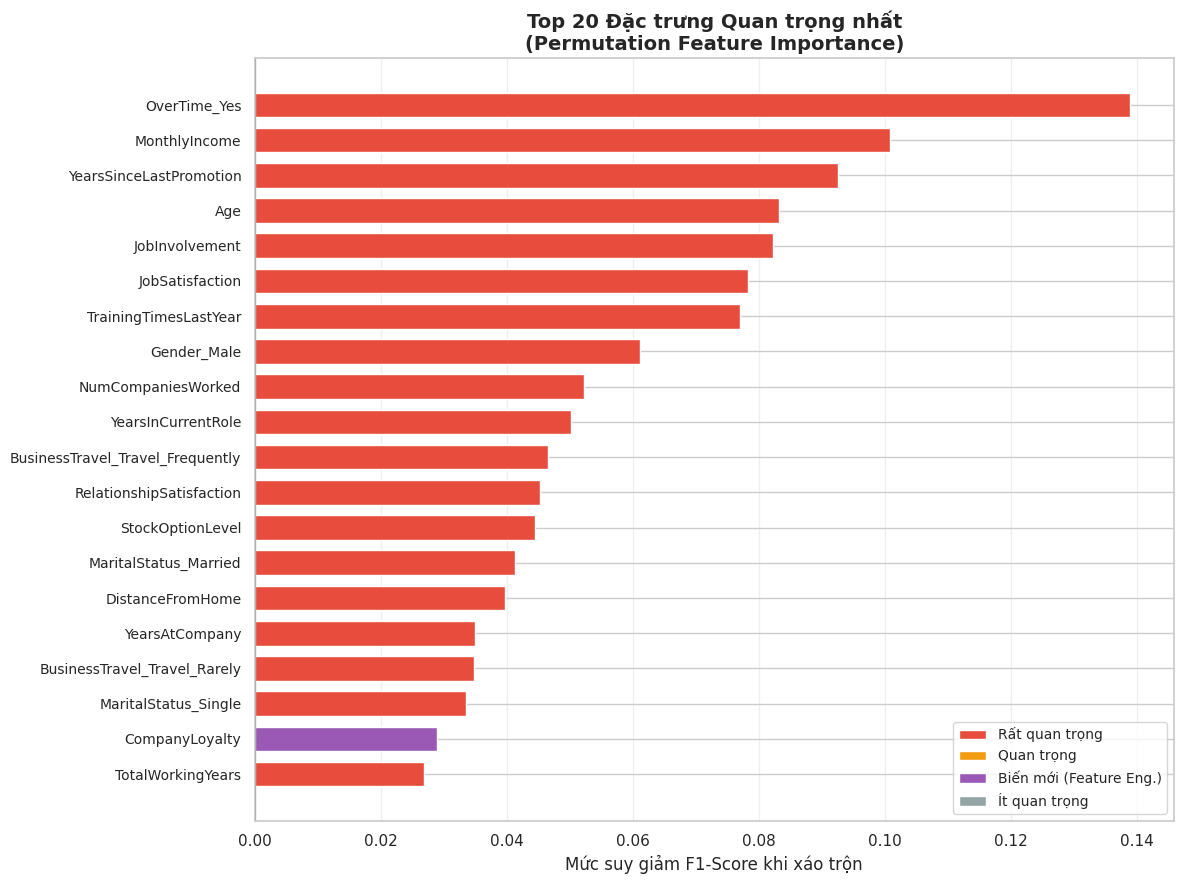

 Đã lưu 'feature_importance.png'


In [15]:
# %% ============================
# CELL 16: PERMUTATION FEATURE IMPORTANCE
# ============================
print("=" * 65)
print("PERMUTATION FEATURE IMPORTANCE")
print("=" * 65)

model.eval()
X_test_tensor = torch.FloatTensor(X_test).to(device)

with torch.no_grad():
    base_proba = torch.sigmoid(model(X_test_tensor)).cpu().numpy().flatten()
    base_preds = (base_proba >= best_threshold).astype(int)
    baseline_f1 = f1_score(y_test, base_preds, zero_division=0)

print(f"\n  Baseline F1: {baseline_f1:.4f}")

n_repeats = 10
importance_scores = []
for i, feat_name in enumerate(feature_names):
    drops = []
    for _ in range(n_repeats):
        X_perm = X_test.copy()
        np.random.shuffle(X_perm[:, i])
        with torch.no_grad():
            proba_p = torch.sigmoid(model(torch.FloatTensor(X_perm).to(device)))
            preds_p = (proba_p.cpu().numpy().flatten() >= best_threshold).astype(int)
        drops.append(baseline_f1 - f1_score(y_test, preds_p, zero_division=0))
    importance_scores.append(np.mean(drops))

feature_importance = pd.DataFrame({
    'Feature': feature_names, 'Importance': importance_scores
}).sort_values('Importance', ascending=False)

print(f"\n  Top 15:")
for i, (_, row) in enumerate(feature_importance.head(15).iterrows(), 1):
    bar = '' * max(1, int(row['Importance'] * 200)) if row['Importance'] > 0 else ''
    print(f"  {i:>3}. {row['Feature']:<30} {row['Importance']:>+.4f}  {bar}")

# Biểu đồ
new_feat_set = set(new_features)
plt.figure(figsize=(12, 9))
top_n = 20
top_feats = feature_importance.head(top_n)
bar_colors = []
for fn in top_feats['Feature'].values:
    imp = top_feats[top_feats['Feature'] == fn]['Importance'].values[0]
    if fn in new_feat_set:
        bar_colors.append('#9b59b6')
    elif imp > 0.01:
        bar_colors.append('#e74c3c')
    elif imp > 0:
        bar_colors.append('#f39c12')
    else:
        bar_colors.append('#95a5a6')

plt.barh(range(len(top_feats)), top_feats['Importance'].values,
         color=bar_colors, edgecolor='white', height=0.7)
plt.yticks(range(len(top_feats)), top_feats['Feature'].values, fontsize=10)
plt.xlabel('Mức suy giảm F1-Score khi xáo trộn', fontsize=12)
plt.title(f'Top {top_n} Đặc trưng Quan trọng nhất\n(Permutation Feature Importance)',
          fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.axvline(x=0, color='black', linewidth=0.8)
plt.grid(axis='x', alpha=0.3)

from matplotlib.patches import Patch
plt.legend(handles=[
    Patch(facecolor='#e74c3c', label='Rất quan trọng'),
    Patch(facecolor='#f39c12', label='Quan trọng'),
    Patch(facecolor='#9b59b6', label='Biến mới (Feature Eng.)'),
    Patch(facecolor='#95a5a6', label='Ít quan trọng'),
], loc='lower right', fontsize=10)

plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Đã lưu 'feature_importance.png'")

In [16]:
# %% ============================
# CELL 17: DỰ BÁO MINH HỌA
# ============================
print("=" * 65)
print("VÍ DỤ DỰ BÁO")
print("=" * 65)

n_samples = 10
sample_indices = np.random.choice(len(X_test), n_samples, replace=False)
print(f"\n{'STT':>4} {'Thực tế':>10} {'Dự đoán':>10} {'Xác suất':>10} {'Kết quả':>10}")
print("-" * 48)
for i, idx in enumerate(sample_indices, 1):
    actual = 'Nghỉ' if y_test_actual[idx] == 1 else 'Ở lại'
    predicted = 'Nghỉ' if y_pred[idx] == 1 else 'Ở lại'
    correct = '' if y_test_actual[idx] == y_pred[idx] else ''
    print(f"  {i:>2}. {actual:>8} {predicted:>10} {y_proba[idx]:>9.2%} {correct:>10}")
print(f"\n  Accuracy: {int((y_test_actual == y_pred).sum())}/{len(y_test_actual)} ({acc:.1%})")

VÍ DỤ DỰ BÁO

 STT    Thực tế    Dự đoán   Xác suất    Kết quả
------------------------------------------------
   1.    Ở lại      Ở lại    32.82%           
   2.    Ở lại      Ở lại     8.15%           
   3.     Nghỉ       Nghỉ    94.35%           
   4.    Ở lại      Ở lại     2.63%           
   5.    Ở lại      Ở lại    45.78%           
   6.    Ở lại      Ở lại    13.28%           
   7.    Ở lại      Ở lại     0.84%           
   8.    Ở lại      Ở lại     0.47%           
   9.    Ở lại      Ở lại    14.13%           
  10.    Ở lại      Ở lại    21.55%           

  Accuracy: 193/221 (87.3%)


In [17]:
# %% ============================
# CELL 18: KẾT LUẬN
# ============================
print("\n" + "=" * 65)
print("TỔNG KẾT DỰ ÁN")
print("=" * 65)
print(f"""

  DỰ ÁN: DỰ ĐOÁN NGUY CƠ NGHỈ VIỆC CỦA NHÂN VIÊN

  Dataset:  IBM HR Analytics (1470 mẫu, 35 biến gốc)
  Mo hinh:  MLP PyTorch - {INPUT_DIM} -> 32 -> 16 -> 1{' ' * (18 - len(str(INPUT_DIM)))}
  Nguong:   {best_threshold:.2f} (F1-Score tren Validation)

  KY THUAT CHONG OVERFITTING:
     Kien truc 32-16 (~{total_params:,} tham so){' ' * (22 - len(str(total_params)))}
     Dropout 0.3
     Regularization (Weight Decay 1e-2)
     Label Smoothing (0.1)
     Augmentation (Gaussian Noise 0.05)
     CosineAnnealingLR

  KẾT QUẢ TEST:
    Accuracy:     {acc:.4f}
    Precision:    {prec:.4f}
    Recall:       {rec:.4f}
    F1-Score:     {f1:.4f}
    ROC-AUC:      {roc_auc:.4f}

""")

print("Output files:")
print("   best_model.pth                 - Mô hình")
print("   eda_plots.png                  - EDA")
print("   correlation_with_attrition.png - Tương quan")
print("   correlation_matrix.png         - Ma trận tương quan")
print("   training_history.png           - Lịch sử train")
print("   test_evaluation.png            - Đánh giá test")
print("   feature_importance.png         - Feature Importance")


TỔNG KẾT DỰ ÁN


  DỰ ÁN: DỰ ĐOÁN NGUY CƠ NGHỈ VIỆC CỦA NHÂN VIÊN

  Dataset:  IBM HR Analytics (1470 mẫu, 35 biến gốc)
  Mo hinh:  MLP PyTorch - 44 -> 32 -> 16 -> 1                
  Nguong:   0.53 (F1-Score tren Validation)

  KY THUAT CHONG OVERFITTING:
     Kien truc 32-16 (~2,081 tham so)                  
     Dropout 0.3
     Regularization (Weight Decay 1e-2)
     Label Smoothing (0.1)
     Augmentation (Gaussian Noise 0.05)
     CosineAnnealingLR

  KẾT QUẢ TEST:
    Accuracy:     0.8733
    Precision:    0.6000
    Recall:       0.6667
    F1-Score:     0.6316
    ROC-AUC:      0.7970


Output files:
   best_model.pth                 - Mô hình
   eda_plots.png                  - EDA
   correlation_with_attrition.png - Tương quan
   correlation_matrix.png         - Ma trận tương quan
   training_history.png           - Lịch sử train
   test_evaluation.png            - Đánh giá test
   feature_importance.png         - Feature Importance
